In [99]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

In [100]:
min_max_data = pd.read_csv("full_min_max_data.csv")
tsne_results = pd.read_csv("tsne_data.csv")

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)


dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


In [101]:
scaled_no_cat_data = min_max_data.drop(['purpose', 'not.fully.paid', 'credit.policy'], axis=1)
scaled_no_cat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3832 entries, 0 to 3831
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dti                3832 non-null   float64
 1   fico               3832 non-null   float64
 2   days.with.cr.line  3832 non-null   float64
 3   revol.bal          3832 non-null   float64
 4   revol.util         3832 non-null   float64
 5   inq.last.6mths     3832 non-null   float64
 6   delinq.2yrs        3832 non-null   float64
 7   pub.rec            3832 non-null   float64
 8   annual.inc         3832 non-null   float64
dtypes: float64(9)
memory usage: 269.6 KB


In [102]:
rfecv_debt = pd.read_csv('rfecv_debt_consolidation.csv')
rfecv_credit = pd.read_csv('rfecv_credit_card.csv')
rfecv_home = pd.read_csv('rfecv_home_improvement.csv')

lasso_debt = pd.read_csv('LassoCV_debt_consolidation.csv')
lasso_credit = pd.read_csv('LassoCV_credit_card.csv')
lasso_home = pd.read_csv('LassoCV_home_improvement.csv')

In [103]:
tsne_results['cat'] = min_max_data['purpose']

---
# Visi požymiai

In [104]:
min_max_data['purpose'].unique()

['all_other', 'credit_card', 'debt_consolidation', 'educational', 'home_improvement', 'major_purchase', 'small_business']
Categories (7, object): ['all_other', 'credit_card', 'debt_consolidation', 'educational', 'home_improvement', 'major_purchase', 'small_business']

In [105]:
full_feature_dfs = {
    'debt_consolidation': scaled_no_cat_data[min_max_data['purpose'] == 'debt_consolidation'],
    'credit_card': scaled_no_cat_data[min_max_data['purpose'] == 'credit_card'],
    'home_improvement': scaled_no_cat_data[min_max_data['purpose'] == 'home_improvement'],
}

wards_clustering_debt = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

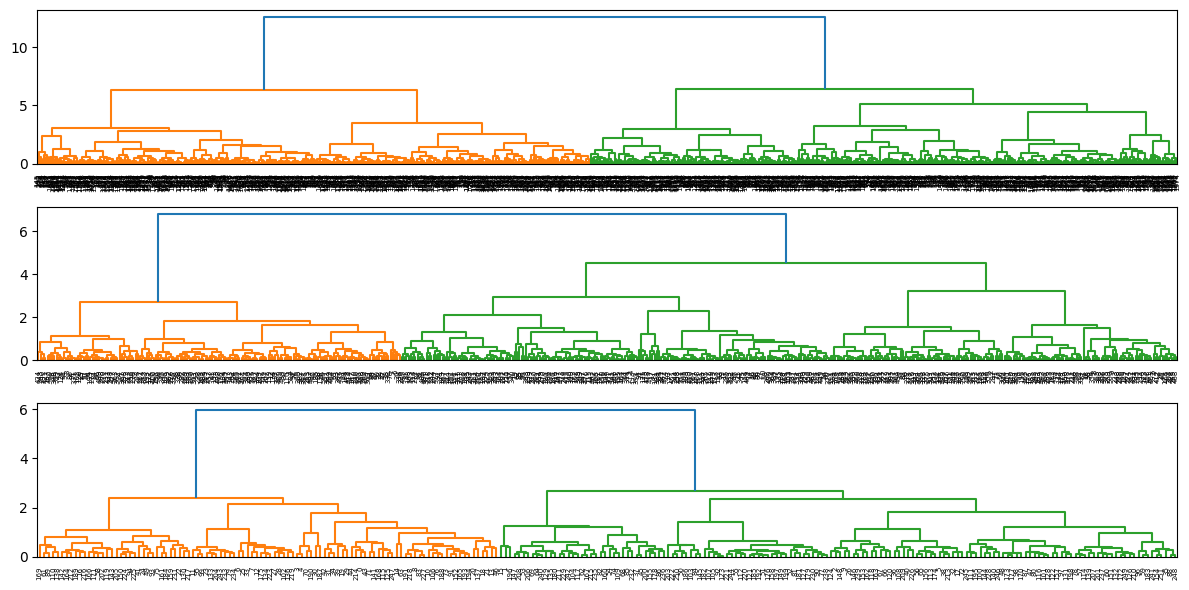

In [106]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 6))

dendrogram(wards_clustering_debt, ax=ax1)
dendrogram(wards_clustering_credit, ax=ax2)
dendrogram(wards_clustering_home, ax=ax3)

plt.tight_layout()
plt.show()

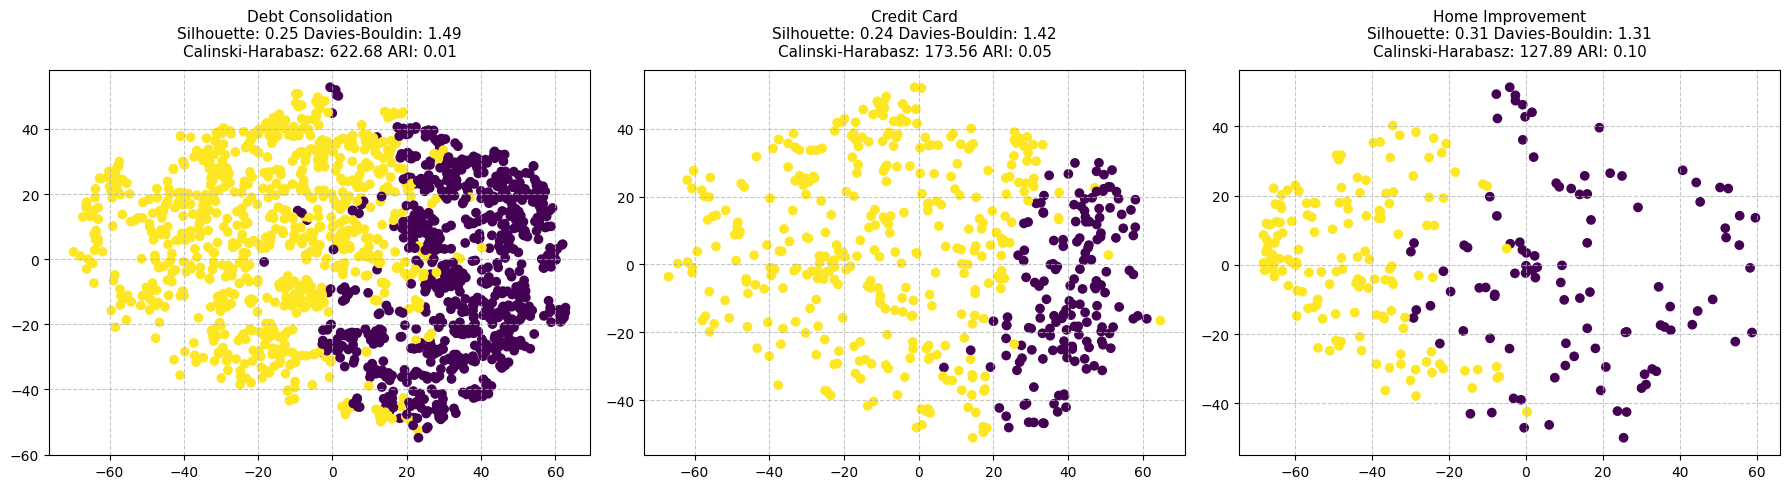

In [107]:
labels_debt = fcluster(wards_clustering_debt, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home, t=2, criterion='maxclust')

true_labels = [min_max_data.loc[min_max_data['purpose'] == 'debt_consolidation', 'credit.policy'],
               min_max_data.loc[min_max_data['purpose'] == 'credit_card', 'credit.policy'],
               min_max_data.loc[min_max_data['purpose'] == 'home_improvement', 'credit.policy']]

tsne_results.loc[tsne_results['cat'] == 'debt_consolidation', 'cluster_label'] = labels_debt
tsne_results.loc[tsne_results['cat'] == 'credit_card', 'cluster_label'] = labels_credit
tsne_results.loc[tsne_results['cat'] == 'home_improvement', 'cluster_label'] = labels_home

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = [
    (silhouette_score(full_feature_dfs['debt_consolidation'], labels_debt),
     davies_bouldin_score(full_feature_dfs['debt_consolidation'], labels_debt),
     calinski_harabasz_score(full_feature_dfs['debt_consolidation'], labels_debt),
     adjusted_rand_score(true_labels[0], labels_debt)),
    (silhouette_score(full_feature_dfs['credit_card'], labels_credit),
     davies_bouldin_score(full_feature_dfs['credit_card'], labels_credit),
     calinski_harabasz_score(full_feature_dfs['credit_card'], labels_credit),
     adjusted_rand_score(true_labels[1], labels_credit)),
    (silhouette_score(full_feature_dfs['home_improvement'], labels_home),
     davies_bouldin_score(full_feature_dfs['home_improvement'], labels_home),
     calinski_harabasz_score(full_feature_dfs['home_improvement'], labels_home),
     adjusted_rand_score(true_labels[2], labels_home)),
]

for i, cat in enumerate(categories):
    subset = tsne_results[tsne_results['cat'] == cat]
    
    axes[i].scatter(subset['tsne_1'], subset['tsne_2'], c=subset['cluster_label'], cmap='viridis')
    title_text = f"{cat.replace('_', ' ').title()}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=11, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
# RFE požymiai

In [108]:
wards_clustering_debt = linkage(rfecv_debt, method="ward", metric="euclidean")
wards_clustering_credit = linkage(rfecv_credit, method="ward", metric="euclidean")
wards_clustering_home = linkage(rfecv_home, method="ward", metric="euclidean")

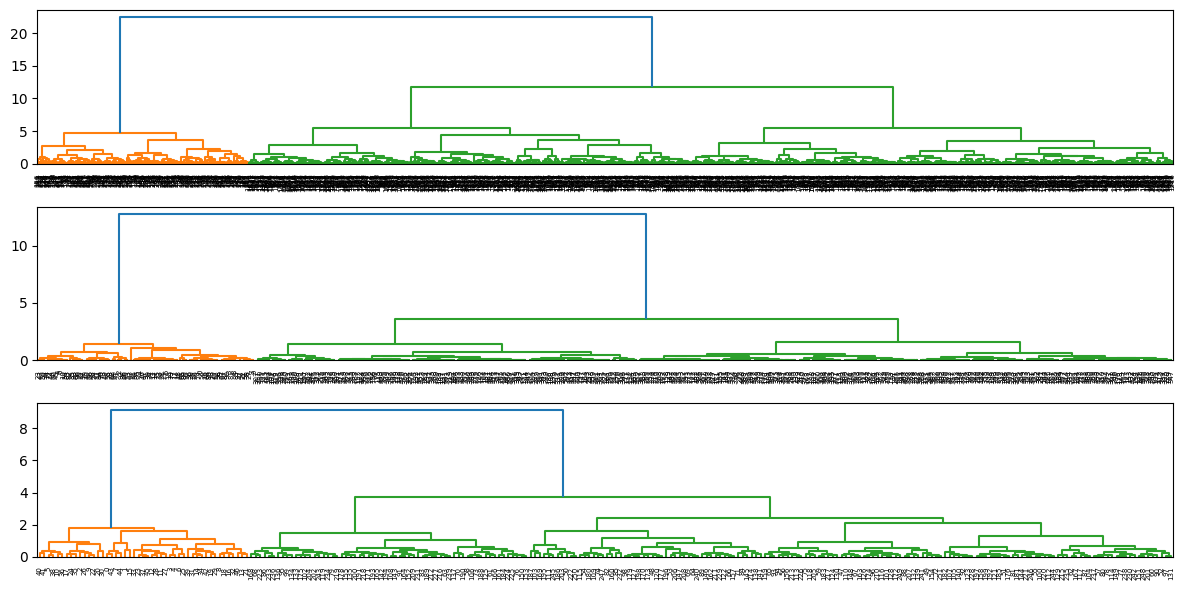

In [109]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 6))

dendrogram(wards_clustering_debt, ax=ax1)
dendrogram(wards_clustering_credit, ax=ax2)
dendrogram(wards_clustering_home, ax=ax3)

plt.tight_layout()
plt.show()

In [110]:
labels_debt = fcluster(wards_clustering_debt, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home, t=2, criterion='maxclust')

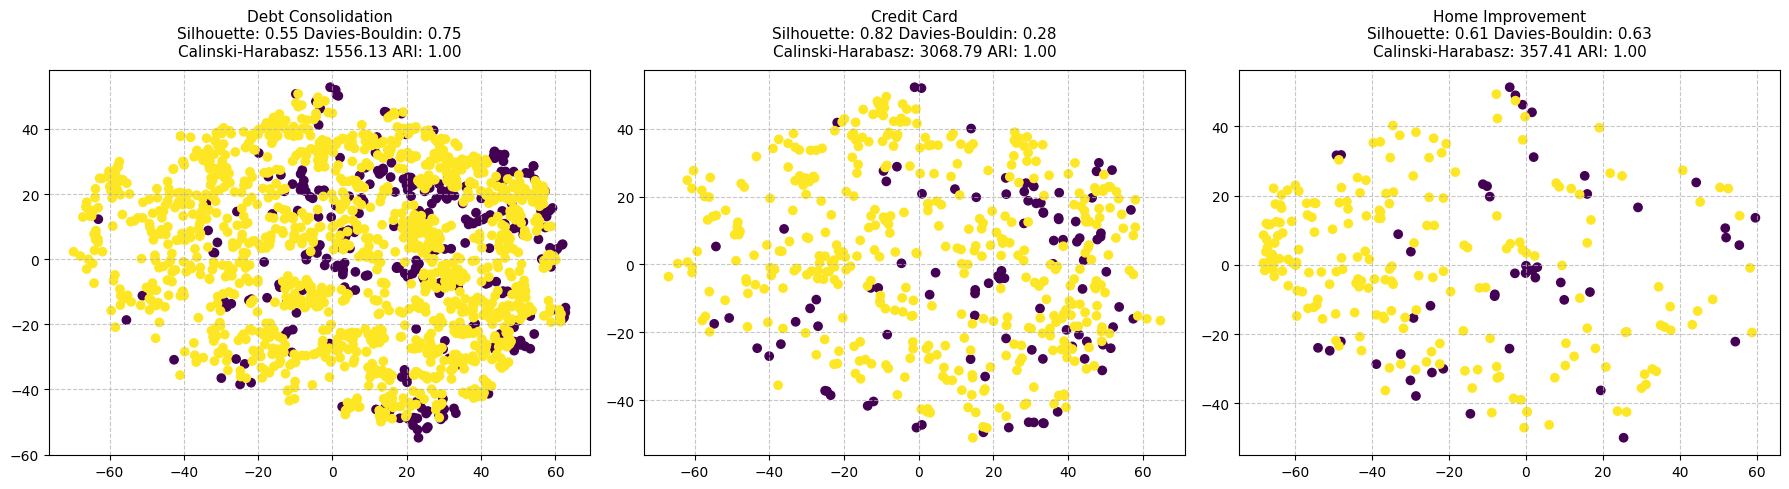

In [111]:
tsne_results.loc[tsne_results['cat'] == 'debt_consolidation', 'cluster_label'] = labels_debt
tsne_results.loc[tsne_results['cat'] == 'credit_card', 'cluster_label'] = labels_credit
tsne_results.loc[tsne_results['cat'] == 'home_improvement', 'cluster_label'] = labels_home

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = [
    (silhouette_score(rfecv_debt, labels_debt), 
     davies_bouldin_score(rfecv_debt, labels_debt), 
     calinski_harabasz_score(rfecv_debt, labels_debt),
     adjusted_rand_score(true_labels[0], labels_debt)),
    (silhouette_score(rfecv_credit, labels_credit), 
     davies_bouldin_score(rfecv_credit, labels_credit), 
     calinski_harabasz_score(rfecv_credit, labels_credit),
     adjusted_rand_score(true_labels[1], labels_credit)),
    (silhouette_score(rfecv_home, labels_home), 
     davies_bouldin_score(rfecv_home, labels_home), 
     calinski_harabasz_score(rfecv_home, labels_home),
     adjusted_rand_score(true_labels[2], labels_home)),
]

for i, cat in enumerate(categories):
    subset = tsne_results[tsne_results['cat'] == cat]
    
    axes[i].scatter(subset['tsne_1'], subset['tsne_2'], c=subset['cluster_label'], cmap='viridis')
    title_text = f"{cat.replace('_', ' ').title()}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=11, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Lasso požymiai

In [112]:
wards_clustering_debt = linkage(lasso_debt, method="ward", metric="euclidean")
wards_clustering_credit = linkage(lasso_credit, method="ward", metric="euclidean")
wards_clustering_home = linkage(lasso_home, method="ward", metric="euclidean")

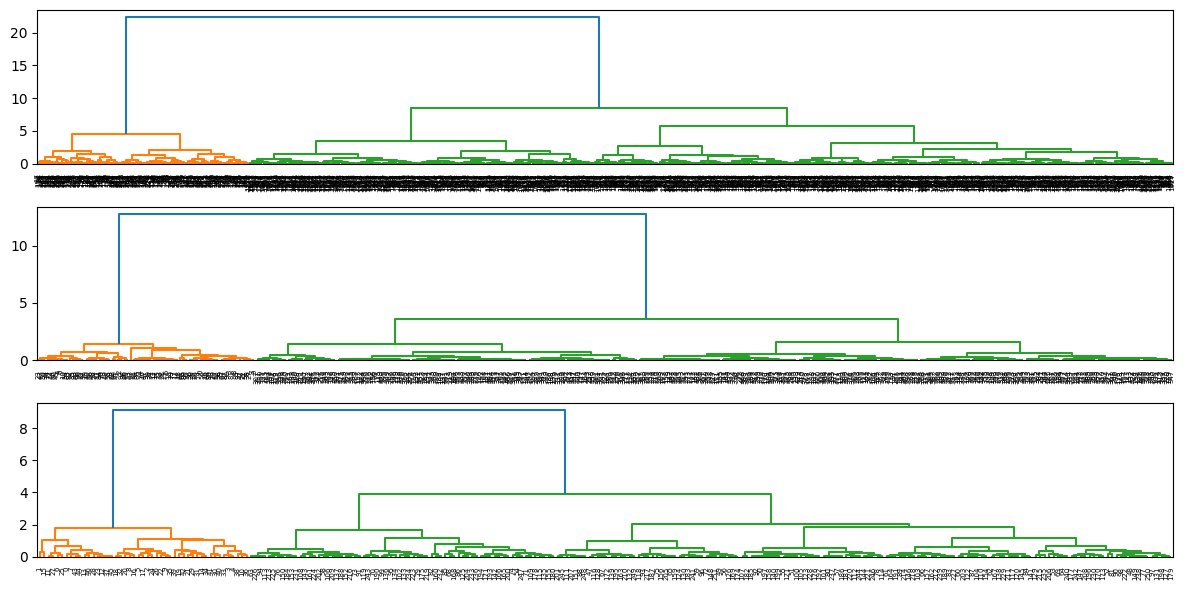

In [113]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 6))

dendrogram(wards_clustering_debt, ax=ax1)
dendrogram(wards_clustering_credit, ax=ax2)
dendrogram(wards_clustering_home, ax=ax3)

plt.tight_layout()
plt.show()

In [114]:
labels_debt = fcluster(wards_clustering_debt, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home, t=2, criterion='maxclust')

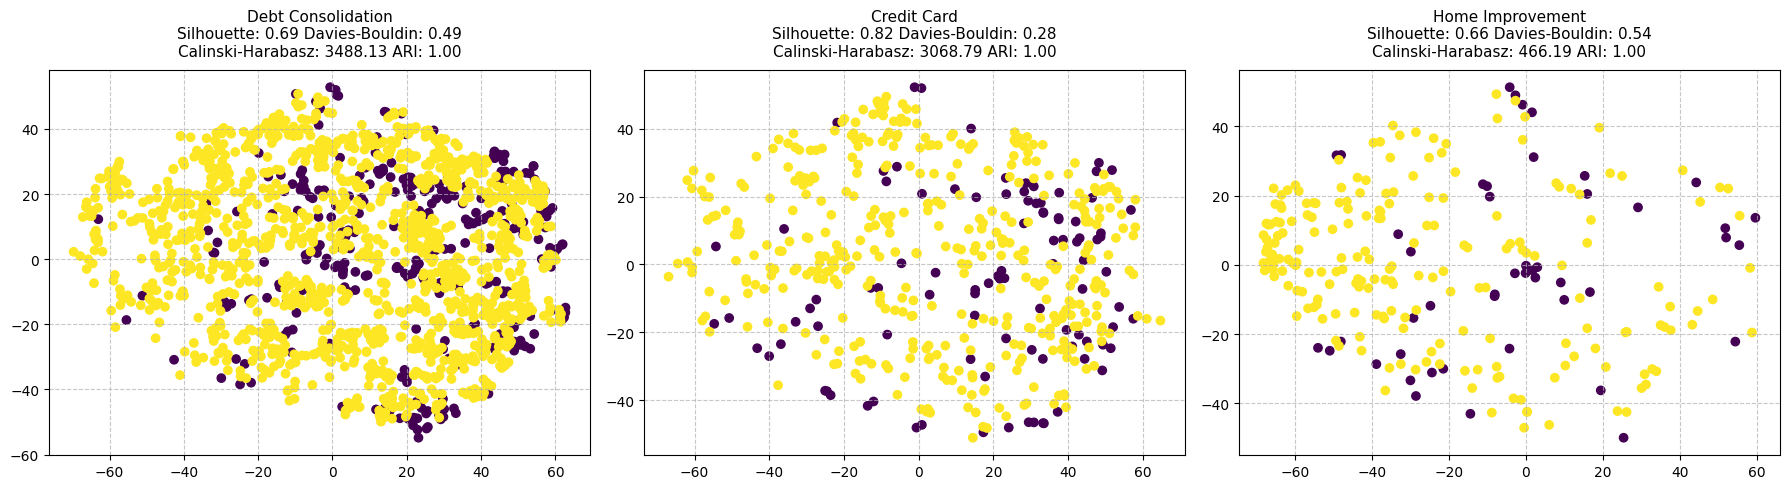

In [115]:
tsne_results.loc[tsne_results['cat'] == 'debt_consolidation', 'cluster_label'] = labels_debt
tsne_results.loc[tsne_results['cat'] == 'credit_card', 'cluster_label'] = labels_credit
tsne_results.loc[tsne_results['cat'] == 'home_improvement', 'cluster_label'] = labels_home

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = [
    (silhouette_score(lasso_debt, labels_debt), 
     davies_bouldin_score(lasso_debt, labels_debt), 
     calinski_harabasz_score(lasso_debt, labels_debt),
     adjusted_rand_score(true_labels[0], labels_debt)),
    (silhouette_score(lasso_credit, labels_credit), 
     davies_bouldin_score(lasso_credit, labels_credit), 
     calinski_harabasz_score(lasso_credit, labels_credit),
     adjusted_rand_score(true_labels[1], labels_credit)),
    (silhouette_score(lasso_home, labels_home), 
     davies_bouldin_score(lasso_home, labels_home), 
     calinski_harabasz_score(lasso_home, labels_home),
     adjusted_rand_score(true_labels[2], labels_home)),
]

for i, cat in enumerate(categories):
    subset = tsne_results[tsne_results['cat'] == cat]
    
    axes[i].scatter(subset['tsne_1'], subset['tsne_2'], c=subset['cluster_label'], cmap='viridis')
    title_text = f"{cat.replace('_', ' ').title()}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=11, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
# t-SNE rinkinys

In [116]:
tsne_wards_clustering_debt = linkage(tsne_results[tsne_results['cat'] == 'debt_consolidation'].iloc[:, :2], method="ward", metric="euclidean")
tsne_wards_clustering_credit = linkage(tsne_results[tsne_results['cat'] == 'credit_card'].iloc[:, :2], method="ward", metric="euclidean")
tsne_wards_clustering_home = linkage(tsne_results[tsne_results['cat'] == 'home_improvement'].iloc[:, :2], method="ward", metric="euclidean")

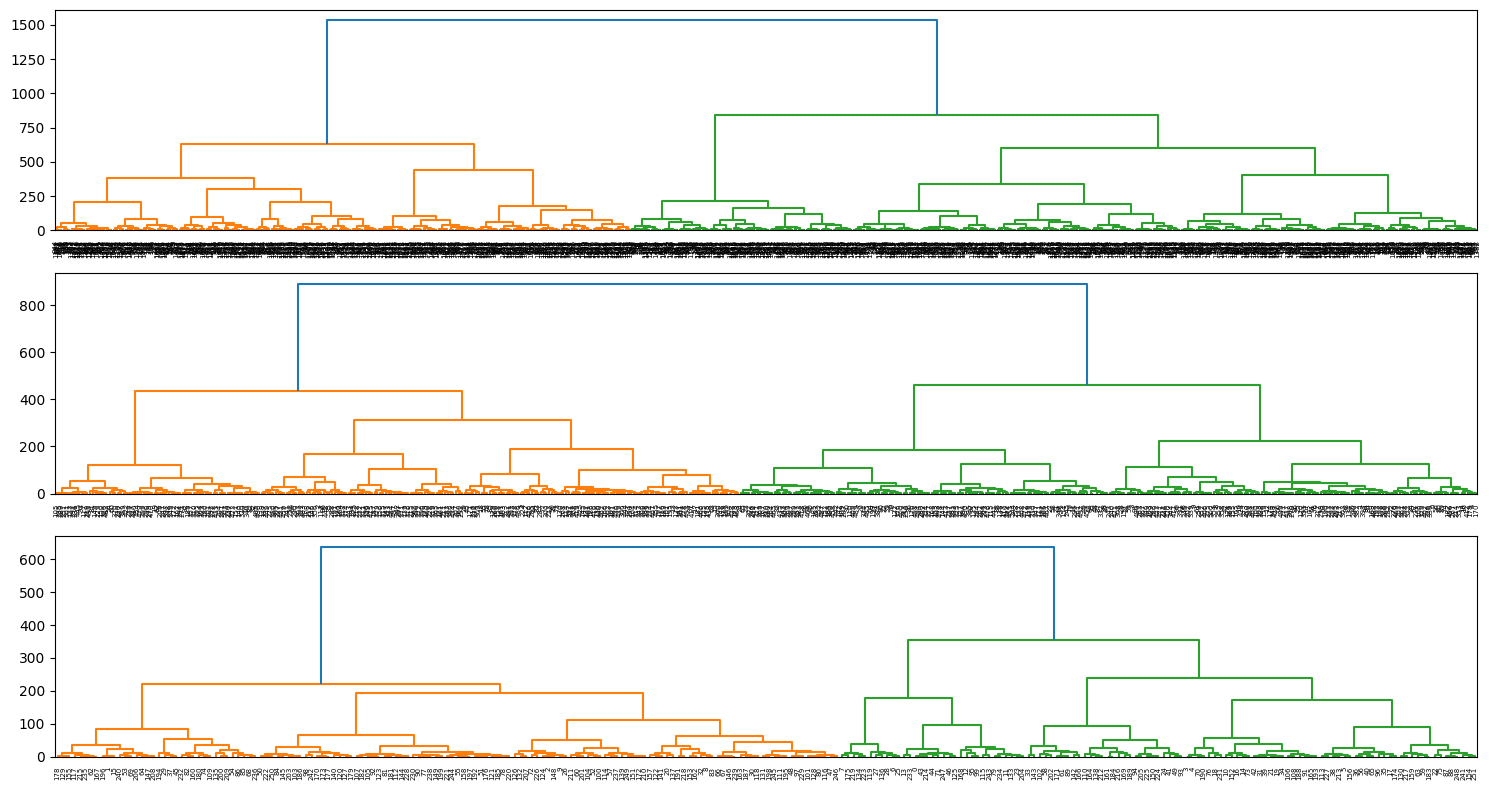

In [117]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8))

dendrogram(tsne_wards_clustering_debt, ax=ax1)
dendrogram(tsne_wards_clustering_credit, ax=ax2)
dendrogram(tsne_wards_clustering_home, ax=ax3)

plt.tight_layout()
plt.show()

In [118]:
labels_debt_tsne = fcluster(tsne_wards_clustering_debt, t=2, criterion='maxclust')
labels_credit_tsne = fcluster(tsne_wards_clustering_credit, t=2, criterion='maxclust')
labels_home_tsne = fcluster(tsne_wards_clustering_home, t=2, criterion='maxclust')

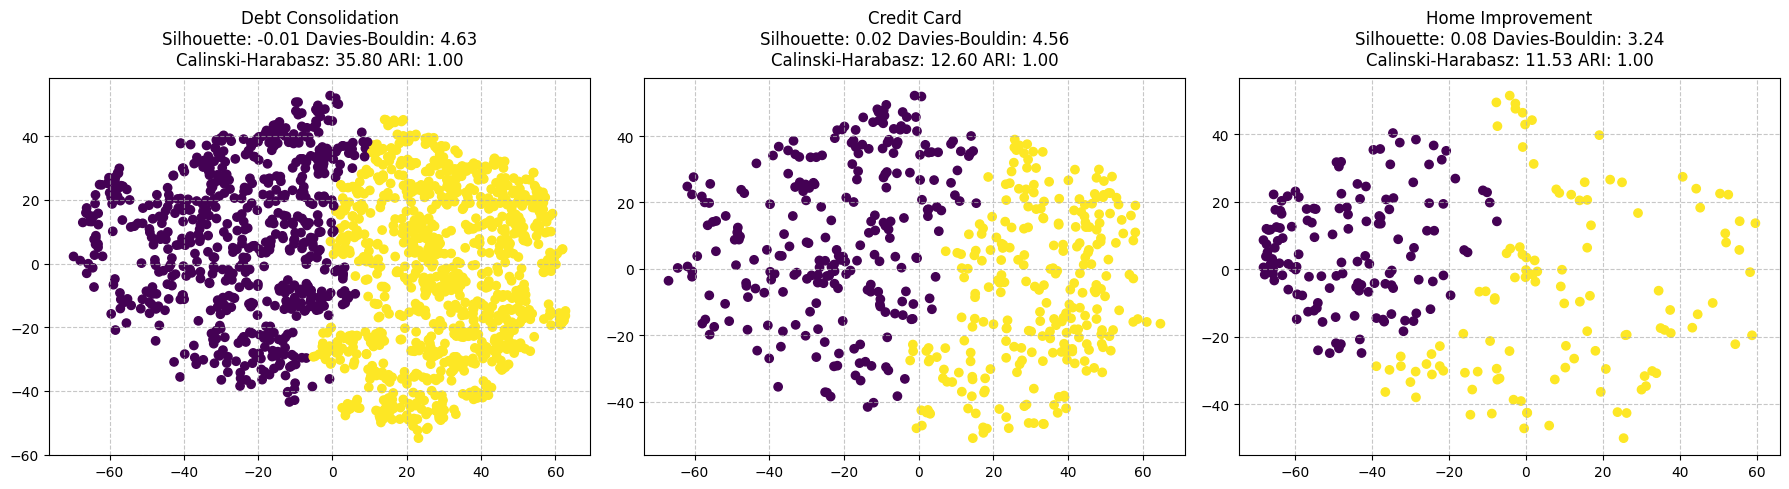

In [119]:
tsne_results.loc[tsne_results['cat'] == 'debt_consolidation', 'cluster_label'] = labels_debt_tsne
tsne_results.loc[tsne_results['cat'] == 'credit_card', 'cluster_label'] = labels_credit_tsne
tsne_results.loc[tsne_results['cat'] == 'home_improvement', 'cluster_label'] = labels_home_tsne

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = [
    (silhouette_score(tsne_results[tsne_results['cat'] == 'debt_consolidation'][['tsne_1', 'tsne_2']], labels_debt),
     davies_bouldin_score(tsne_results[tsne_results['cat'] == 'debt_consolidation'][['tsne_1', 'tsne_2']], labels_debt),
     calinski_harabasz_score(tsne_results[tsne_results['cat'] == 'debt_consolidation'][['tsne_1', 'tsne_2']], labels_debt),
     adjusted_rand_score(true_labels[0], labels_debt)
     ),
    (silhouette_score(tsne_results[tsne_results['cat'] == 'credit_card'][['tsne_1', 'tsne_2']], labels_credit),
     davies_bouldin_score(tsne_results[tsne_results['cat'] == 'credit_card'][['tsne_1', 'tsne_2']], labels_credit),
     calinski_harabasz_score(tsne_results[tsne_results['cat'] == 'credit_card'][['tsne_1', 'tsne_2']], labels_credit),
     adjusted_rand_score(true_labels[1], labels_credit)
     ),
    (silhouette_score(tsne_results[tsne_results['cat'] == 'home_improvement'][['tsne_1', 'tsne_2']], labels_home),
     davies_bouldin_score(tsne_results[tsne_results['cat'] == 'home_improvement'][['tsne_1', 'tsne_2']], labels_home),
     calinski_harabasz_score(tsne_results[tsne_results['cat'] == 'home_improvement'][['tsne_1', 'tsne_2']], labels_home),
     adjusted_rand_score(true_labels[2], labels_home)
     ),
]

for i, cat in enumerate(categories):
    subset = tsne_results[tsne_results['cat'] == cat]
    
    axes[i].scatter(subset['tsne_1'], subset['tsne_2'], c=subset['cluster_label'], cmap='viridis')
    title_text = f"{cat.replace('_', ' ').title()}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=12, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()